<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Legume Tutorial: Bound States in a Continuum and Q-factors
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>January, 2025</font></center>

***

In [1]:
import numpy as np
import legume
import matplotlib.pyplot as plt
import copy

print(f"Version of the imported legume : {legume.__version__}")

plt.rcParams["font.family"] = "Helvetica"
%matplotlib inline
%config InlineBackend.figure_format='svg'


Version of the imported legume : 1.0.3


## Define the PhC 

The PhC slab consists of a square lattice of period $a=400$ nm, hole radius $r=100$ nm, etched in a suspended slab of thickness $d=80$ nm with refractive index $n=3.45$. It is the same parameters of Fig. 8 of the CPC paper, but we use dimensionless units here.

In [2]:
D = 0.2  # slab thickness in units of a
r = 0.25  # hole radius in units of a
eps_c = 1          # permittivity of circular holes
eps_b = 3.45**2    # background permittivity of slab
eps_lower, eps_upper = 1, 1  # permittivities of lower and upper claddings

lattice = legume.Lattice('square')
phc = legume.PhotCryst(lattice, eps_l=eps_lower, eps_u=eps_upper)
phc.add_layer(d=D, eps_b=eps_b)
phc.layers[-1].add_shape(legume.Circle(eps=eps_c, r=r, x_cent=0., y_cent=0))

gme = legume.GuidedModeExp(phc, gmax=4.5, truncate_g='abs')
npw = np.shape(gme.gvec)[1]  # number of plane waves in the expansion
print('Number of reciprocal lattice vectors in the expansion: npw = ', npw)

Number of reciprocal lattice vectors in the expansion: npw =  69


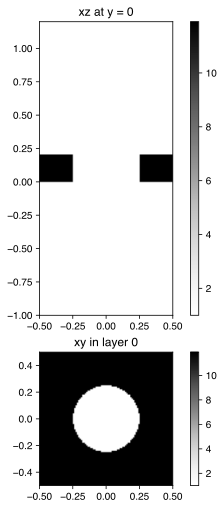

In [3]:
# Visualize what we built
legume.viz.structure(phc, xz=True, xy=True, figsize=3, Nz=300)

Plot the photonic bands and Q-factors

In the **legume** 1.0.0 version, `viz.bands` plots the frequencies as a function of wavevector along the path in the Brillouin zone by means of the kw argument `k_units=True`, which requires setting the xticks with `path['k_indexes']`.

In [4]:
# Run the guided-mode expansion
numeig, verbose = 20, True
nk = 50
path = lattice.bz_path(['X', 'G', 'M'], [nk, int(nk*np.sqrt(2))])

gme.run(kpoints=path['kpoints'], gmode_inds=[
        0, 1, 2, 3], numeig=numeig, verbose=True)
freqs = np.asarray(gme.freqs, dtype=float)
freqs_im = np.asarray(gme.freqs_im, dtype=float)

nkappa, nfreq = freqs.shape[0], freqs.shape[1]
print(f'Number of wavevectors = {nkappa}, number of frequencies = {nfreq}')


10.524s total time for real part of frequencies in GuidedModeExp, of which
  3.149s (30%) for guided modes computation using the gmode_compute='exact' method
  0.001s (0%) for inverse matrix of Fourier-space permittivity
  5.991s (57%) for matrix diagionalization using the 'eigh' solver
  1.335s (13%) for creating GME matrix
7.051s  total time for imaginary part of frequencies███████│ 121 of 121
Number of wavevectors = 121, number of frequencies = 20


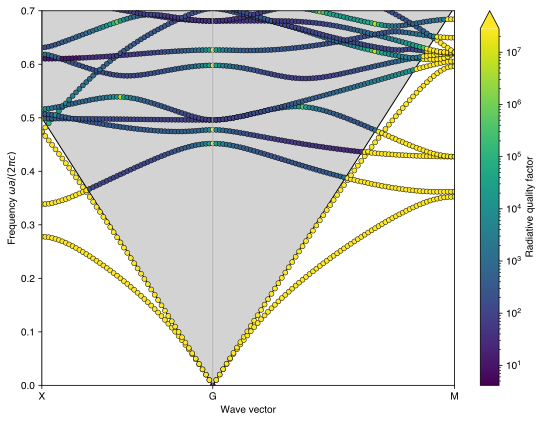

In [5]:
# Plot the band structure with Q factors
def plot_bands_Q(gme):
    fig, ax = plt.subplots(1, figsize=(8, 6))
    legume.viz.bands(gme, Q=True, ax=ax, cone=True, k_units=True, conecolor='lightgray',
                     markersize=5, markeredgecolor='black', markeredgewidth=0.5)
    for collection in ax.collections:
        collection.set_edgecolor('black')
        # collection.set_linewidth(0.5)
    ax.set_xticks(path['k_indexes'])
    ax.set_xticklabels(path['labels'])
    ax.xaxis.grid('True')
    ax.set_ylim([0., 0.7])
    fig.tight_layout()
    
plot_bands_Q(gme)

## Study of a symmetry-proteceted BIC

We see that there are several states at ${\bf k}=0$ with $Q\rightarrow\infty$, which are symmetry-protected BICs. In the square lattice, all nondegenerate states at the $\Gamma$ point are symmetry-protected BICs, and vice-versa (while the hexagonal lattice supports twofold degenerate BICs: see example 08).

Here we focus on the lowest BIC with a dimensionless frequency around 0.45, which is called BIC1 in Fig. 8(a) of the CPC paper. Let's plot the Q-factor close to ${\bf k}=0$: for this, however, we need a denser set of ${\bf k}$-points and we focus on a region closer to the $\Gamma$ point. We define the points $X_1=[0.1\pi,0]$ and $M_1=[0.1\pi,0.1\pi]$ and we calculate for wavevectors in the path $X_1\to\Gamma\to M_1$.

We now want to plot the Q-factor versus the wavevector for the chosen mode, which has index jmode=2.

But there is an annoying issue we should fix: unfortunately the photonic bands are discontinuous at ${\bf k}=0$, as the code calculates one less frequency there.

In [6]:
# Run the guided-mode expansion close to Gamma
numeig, verbose = 20, True
nk = 50

X1 = [0.1*np.pi, 0]
M1 = [0.1*np.pi, 0.1*np.pi]
path = lattice.bz_path([X1, 'G', M1], [nk, int(np.sqrt(2)*nk)])

gme = legume.GuidedModeExp(phc, gmax=4.5, truncate_g='abs')
gme.run(kpoints=path['kpoints'], gmode_inds=[
        0, 1, 2, 3], numeig=numeig, verbose=True)
freqs = np.asarray(gme.freqs, dtype=float)
freqs_im = np.asarray(gme.freqs_im, dtype=float)
nkappa, nfreq = freqs.shape[0], freqs.shape[1]
print(f'Number of wavevectors = {nkappa}, number of frequencies = {nfreq}')


10.627s total time for real part of frequencies in GuidedModeExp, of which
  3.220s (30%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  6.062s (57%) for matrix diagionalization using the 'eigh' solver
  1.298s (12%) for creating GME matrix
6.707s  total time for imaginary part of frequencies███████│ 121 of 121
Number of wavevectors = 121, number of frequencies = 20


In [7]:
# Compute the parallel wavevector and the x-axis values for plotting
k_points = np.asarray(path['kpoints'], dtype=float)
k_parallel = np.linalg.norm(k_points, axis=0) / (2 * np.pi)
gamma_index = int(np.argmin(k_parallel))
step_lengths = np.linalg.norm(np.diff(k_points, axis=1), axis=0)
x_plot = np.concatenate(([0.0], np.cumsum(step_lengths)))
x_points = np.broadcast_to(x_plot[:, None], freqs.shape)


def nearest_frequency_order(reference, candidates):
    """Order candidates so each value follows the nearest previous band."""
    order = []
    unused = list(range(len(candidates)))
    for target in reference:
        j_best = min(unused, key=lambda j: abs(candidates[j] - target))
        order.append(j_best)
        unused.remove(j_best)
    return np.asarray(order, dtype=int)


def track_bands_by_frequency(freqs, reference_index):
    """Track sorted eigenvalues into continuous branches along the k path."""
    freqs = np.asarray(freqs, dtype=float)
    tracked = np.empty_like(freqs)
    orders = np.empty(freqs.shape, dtype=int)

    tracked[reference_index] = freqs[reference_index]
    orders[reference_index] = np.arange(freqs.shape[1])

    for ik in range(reference_index + 1, freqs.shape[0]):
        order = nearest_frequency_order(tracked[ik - 1], freqs[ik])
        tracked[ik] = freqs[ik, order]
        orders[ik] = order

    for ik in range(reference_index - 1, -1, -1):
        order = nearest_frequency_order(tracked[ik + 1], freqs[ik])
        tracked[ik] = freqs[ik, order]
        orders[ik] = order

    return tracked, orders


# Start from the last nonzero-k point before Gamma. At Gamma the raw sorted
# eigenvalue columns can shift because several modes are degenerate there.
tracking_reference_index = max(gamma_index - 1, 0)
freqs_tracked, band_orders = track_bands_by_frequency(
    freqs, tracking_reference_index
)


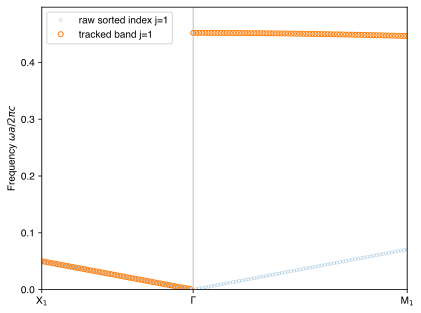

In [8]:
jmode = 1 # band index to plot
fig, ax = plt.subplots(1, figsize=(6, 4.5))
ax.plot(x_plot, freqs[:, jmode], 'o', markersize=3,
        markerfacecolor='none', markeredgewidth=0.6, alpha=0.35,
        label=f'raw sorted index j={jmode}')
ax.plot(x_plot, freqs_tracked[:, jmode], 'o', markersize=5,
        markerfacecolor='none', markeredgewidth=1.0,
        label=f'tracked band j={jmode}')
tick_locs = [x_plot[0], x_plot[gamma_index], x_plot[-1]]
tick_labs = [r'X$_1$', r'$\Gamma$', r'M$_1$']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs)
ax.xaxis.grid(True)
ax.set_xlim([x_plot[0], x_plot[-1]])
ax.set_ylabel(r'Frequency $\omega a/2\pi c$')
ax.legend(loc='best')
ymax = np.nanmax([freqs[:, jmode].max(), freqs_tracked[:, jmode].max()])
ax.set_ylim([0., ymax*1.1])
fig.tight_layout()
